# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

In [3]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [4]:
from sklearn.model_selection import cross_val_score

rows = []
for d in [1, 2, 3, 4, 5, None]:
    m = DecisionTreeClassifier(criterion="gini", max_depth=d, min_samples_leaf=2, random_state=42)
    m.fit(X_train, y_train)
    cv = cross_val_score(m, X_train, y_train, cv=5).mean()
    rows.append([str(d), m.get_depth(), m.get_n_leaves(),
                 m.score(X_train, y_train), m.score(X_test, y_test), cv])

pd.DataFrame(rows, columns=["max_depth", "실제 깊이", "리프 수", "train acc", "test acc", "5-fold CV"])

,max_depth,실제 깊이,리프 수,train acc,test acc,5-fold CV
0,1,1,2,0.675000,0.633333,0.675000
1,2,2,3,0.950000,0.966667,0.916667
2,3,3,5,0.950000,1.000000,0.933333
3,4,4,7,0.966667,1.000000,0.916667
4,5,5,8,0.975000,1.000000,0.908333
5,None,5,8,0.975000,1.000000,0.908333


**Q1.1 답**

`max_depth`는 트리가 질문을 몇 단계까지 이어갈 수 있는지를 정하는 상한입니다. 리프 수가 2^depth 이하로 묶이므로 구조가 먼저 변하고, 성능은 그 결과로 따라옵니다.

| max_depth | 실제 깊이 | 리프 수 | train | test | 5-fold CV |
|---|---|---|---|---|---|
| 1 | 1 | 2 | 0.675 | 0.633 | 0.675 |
| 2 | 2 | 3 | 0.950 | 0.967 | 0.917 |
| 3 | 3 | 5 | 0.950 | 1.000 | **0.933** |
| 4 | 4 | 7 | 0.967 | 1.000 | 0.917 |
| 5 | 5 | 8 | 0.975 | 1.000 | 0.908 |
| None | 5 | 8 | 0.975 | 1.000 | 0.908 |

**구조 쪽**

깊이 1이면 리프가 2개뿐이라 세 클래스 중 하나는 아예 예측 대상에서 빠집니다. train 정확도 0.675는 setosa 40개를 전부 맞히고 남은 80개를 versicolor 한 덩어리로 몰아서 나온 값입니다(40 + 41 = 81, 81/120 = 0.675).

깊이를 1씩 늘리면 리프가 2 → 3 → 5 → 7 → 8로 늘고 5에서 멈춥니다. `max_depth=None`으로 제한을 풀어도 결과가 깊이 5와 같은데, `min_samples_leaf=2`가 먼저 걸리기 때문입니다. 제한을 푼다고 트리가 무한히 자라는 게 아니라 다른 정지 조건에서 멈춘다는 점이 눈에 띄었습니다.

**성능 쪽**

train 정확도는 깊이를 늘릴수록 단조 증가합니다(0.675 → 0.975). 반면 5-fold CV는 깊이 3에서 0.933으로 가장 높고 그 뒤로는 떨어집니다. 깊이 4 이상에서 늘어난 표현력이 train에만 쓰이고 있다고 판단했습니다.

test 정확도는 깊이 3부터 1.000으로 고정되는데, 이 값으로 깊이를 고르는 건 위험해 보입니다. test가 30개뿐이라 눈금이 1/30 = 0.033이고, train(0.950)보다 test(1.000)가 높다는 것 자체가 테스트 표본이 우연히 쉬웠다는 신호에 가깝습니다. 그래서 위 표는 CV 열을 기준으로 읽었습니다.

줄이면, iris에서는 깊이 2~3에서 할 수 있는 일이 끝나고 그 뒤는 과적합 구간입니다.

### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

In [5]:
from sklearn.tree import export_text

for crit in ["gini", "entropy"]:
    m = DecisionTreeClassifier(criterion=crit, max_depth=3, min_samples_leaf=2, random_state=42)
    m.fit(X_train, y_train)
    print(f"[{crit}] train {m.score(X_train, y_train):.4f} / test {m.score(X_test, y_test):.4f} / 리프 {m.get_n_leaves()}개")
    print(export_text(m, feature_names=list(X.columns)))

gini_acc, ent_acc = [], []
for s in range(30):
    a, b, c, d = train_test_split(X, y, test_size=0.2, random_state=s)
    gini_acc.append(DecisionTreeClassifier(criterion="gini", max_depth=3,
                                           min_samples_leaf=2, random_state=42).fit(a, c).score(b, d))
    ent_acc.append(DecisionTreeClassifier(criterion="entropy", max_depth=3,
                                          min_samples_leaf=2, random_state=42).fit(a, c).score(b, d))
gini_acc, ent_acc = np.array(gini_acc), np.array(ent_acc)

print(f"분할 시드 30개 평균 test 정확도 — gini {gini_acc.mean():.4f} / entropy {ent_acc.mean():.4f}")
print(f"완전히 같은 결과 {(gini_acc == ent_acc).sum()}회 / "
      f"gini 승 {(gini_acc > ent_acc).sum()}회 / entropy 승 {(ent_acc > gini_acc).sum()}회")

[gini] train 0.9500 / test 1.0000 / 리프 5개
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.55
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.55
|   |   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2

[entropy] train 0.9500 / test 1.0000 / 리프 5개
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.55
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.55
|   |   |   |--- class: 1
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



분할 시드 30개 평균 test 정확도 — gini 0.9478 / entropy 0.9489
완전히 같은 결과 26회 / gini 승 1회 / entropy 승 3회


**Q1.2 답**

둘 다 한 노드가 얼마나 섞여 있는지를 재는 값이고, 한 클래스만 남으면 0이 됩니다.

- 지니 = 1 − Σ p²  → 그 노드에서 무작위로 둘을 뽑았을 때 서로 다른 클래스일 확률
- 엔트로피 = − Σ p·log₂p  → 그 노드의 클래스를 알아내는 데 필요한 평균 정보량(비트)

차이는 곡선의 모양입니다. 이진 분류에서 p = 0.5일 때 지니는 0.5, 엔트로피는 1이고, 로그를 쓰는 엔트로피 쪽이 확률이 0에 가까운 소수 클래스에 더 큰 벌점을 줍니다. 그래서 이론적으로는 엔트로피가 조금 더 균형 잡힌 분할을, 지니가 조금 더 큰 덩어리를 떼어내는 분할을 선호합니다. 계산은 로그가 없는 지니가 가볍고, sklearn 기본값도 지니입니다.

**그런데 이 데이터에서는 두 기준이 만든 트리가 완전히 같았습니다.** 위 `export_text` 출력이 분기 변수·임계값까지 한 글자도 다르지 않고, train/test 정확도와 리프 수도 동일합니다.

분할 시드를 0~29로 바꿔 30번 반복해도 마찬가지였습니다.

| 기준 | 30개 시드 평균 test 정확도 |
|---|---|
| gini | 0.9478 |
| entropy | 0.9489 |

30번 중 26번은 두 기준의 정확도가 완전히 같았고, 갈린 4번도 gini 1승 · entropy 3승이었습니다. 평균 차이 0.001은 시드를 바꿀 때 생기는 변동보다 훨씬 작습니다.

두 지표가 분할 후보에 **거의 같은 순위**를 매기기 때문이라고 생각합니다. 분할을 고르는 문제에서는 불순도의 절대값이 아니라 후보들 사이의 순서만 맞으면 같은 답이 나오는데, 지니와 엔트로피는 모양이 다를 뿐 같은 방향으로 움직이니 순서가 뒤집히는 일이 드물었던 것으로 보입니다.

정리하면 이 데이터에서 결과를 좌우한 건 `criterion`이 아니라 `max_depth`였습니다. 클래스가 심하게 불균형하면 소수 클래스에 벌점을 더 주는 엔트로피 쪽이 달라질 수도 있을 것 같은데, iris로는 확인할 수 없는 지점입니다.

### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

In [6]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

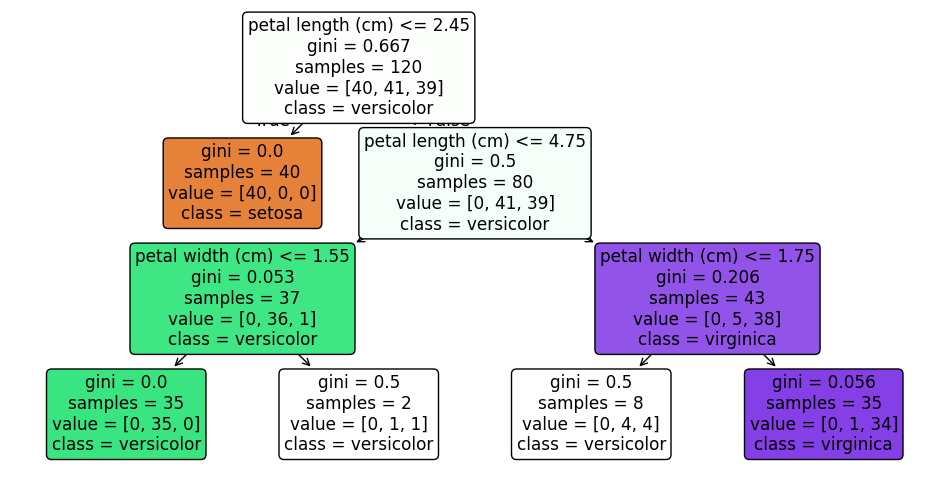

In [7]:
# 그래프 출력
graph = graphviz.Source(dot_data)
try:
    graph.pipe(format="svg")        # Graphviz 실행 파일이 있는지 확인
    display(graph)
except graphviz.ExecutableNotFound:
    from sklearn.tree import plot_tree
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_tree(tree_model, feature_names=list(X.columns), class_names=list(iris.target_names),
              filled=True, rounded=True, ax=ax)
    plt.show()

In [8]:
t = tree_model.tree_

for i in range(t.node_count):
    n = int(t.n_node_samples[i])
    cnt = (t.value[i][0] * n).round().astype(int)
    dist = " / ".join(str(v) for v in cnt)
    if t.children_left[i] == -1:
        print(f"노드 {i}: [리프]  n={n:3d}  gini={t.impurity[i]:.4f}  분포 {dist}"
              f"  → 예측 {iris.target_names[cnt.argmax()]}")
    else:
        print(f"노드 {i}: {X.columns[t.feature[i]]} <= {t.threshold[i]:.3f}  n={n:3d}"
              f"  gini={t.impurity[i]:.4f}  분포 {dist}"
              f"  → 참 {t.children_left[i]}번 / 거짓 {t.children_right[i]}번")

l, r = t.children_left[0], t.children_right[0]
after = (t.n_node_samples[l] * t.impurity[l] + t.n_node_samples[r] * t.impurity[r]) / t.n_node_samples[0]
print(f"\n분포는 (setosa / versicolor / virginica) 순")
print(f"루트 분할의 불순도: {t.impurity[0]:.4f} → {after:.4f} (감소량 {t.impurity[0] - after:.4f})")

노드 0: petal length (cm) <= 2.450  n=120  gini=0.6665  분포 40 / 41 / 39  → 참 1번 / 거짓 2번
노드 1: [리프]  n= 40  gini=0.0000  분포 40 / 0 / 0  → 예측 setosa
노드 2: petal length (cm) <= 4.750  n= 80  gini=0.4997  분포 0 / 41 / 39  → 참 3번 / 거짓 6번
노드 3: petal width (cm) <= 1.550  n= 37  gini=0.0526  분포 0 / 36 / 1  → 참 4번 / 거짓 5번
노드 4: [리프]  n= 35  gini=0.0000  분포 0 / 35 / 0  → 예측 versicolor
노드 5: [리프]  n=  2  gini=0.5000  분포 0 / 1 / 1  → 예측 versicolor
노드 6: petal width (cm) <= 1.750  n= 43  gini=0.2055  분포 0 / 5 / 38  → 참 7번 / 거짓 8번
노드 7: [리프]  n=  8  gini=0.5000  분포 0 / 4 / 4  → 예측 versicolor
노드 8: [리프]  n= 35  gini=0.0555  분포 0 / 1 / 34  → 예측 virginica

분포는 (setosa / versicolor / virginica) 순
루트 분할의 불순도: 0.6665 → 0.3331 (감소량 0.3334)


**Q1.3 답**

분할 기준을 고르는 방식부터 적으면, 각 노드에서 (변수, 임계값) 후보를 전부 훑어 **자식 노드 지니의 표본 수 가중평균을 가장 많이 낮추는 하나**를 고릅니다. 임계값 후보는 그 변수의 정렬된 값에서 이웃한 두 값의 중간점입니다.

`max_depth=3`, `min_samples_leaf=2`, gini로 학습한 트리는 아래와 같습니다. 분포는 (setosa / versicolor / virginica) 순이고, train 120개는 40 / 41 / 39로 나뉘어 있습니다.

| 노드 | 분할 조건 | n | gini | 분포 | 자식 |
|---|---|---|---|---|---|
| 0 (루트) | petal length ≤ 2.45 | 120 | 0.667 | 40 / 41 / 39 | 1, 2 |
| 1 | 리프 | 40 | 0.000 | 40 / 0 / 0 → **setosa** | |
| 2 | petal length ≤ 4.75 | 80 | 0.500 | 0 / 41 / 39 | 3, 6 |
| 3 | petal width ≤ 1.55 | 37 | 0.053 | 0 / 36 / 1 | 4, 5 |
| 4 | 리프 | 35 | 0.000 | 0 / 35 / 0 → **versicolor** | |
| 5 | 리프 | 2 | 0.500 | 0 / 1 / 1 → versicolor | |
| 6 | petal width ≤ 1.75 | 43 | 0.206 | 0 / 5 / 38 | 7, 8 |
| 7 | 리프 | 8 | 0.500 | 0 / 4 / 4 → versicolor | |
| 8 | 리프 | 35 | 0.056 | 0 / 1 / 34 → **virginica** | |

읽으면서 눈에 띈 것들입니다.

**첫 분할이 압도적입니다.** `petal length ≤ 2.45` 하나로 지니가 0.667 → 0.333으로 떨어지고, setosa 40개가 오염 없이 통째로 빠져나갑니다(노드 1, gini 0). 이후 분할들은 남은 versicolor·virginica를 가르는 훨씬 어려운 문제를 다룹니다.

**네 변수 중 두 개만 쓰였습니다.** petal length와 petal width만 등장하고 sepal 쪽은 한 번도 선택되지 않았습니다. 꽃잎 두 변수가 이미 종을 거의 결정하기 때문으로 보입니다.

**순수해지지 못한 채 멈춘 리프가 둘 있습니다.** 노드 5(2개, 1:1)와 노드 7(8개, 4:4)은 지니가 0.5인 채로 리프가 되었습니다. 더 나눌 수 없어서가 아니라 `max_depth=3`에 걸려서입니다. 특히 노드 7은 petal length > 4.75이면서 petal width ≤ 1.75인 구간인데, 두 종의 경계가 정확히 여기를 지납니다. 동점일 때 sklearn은 인덱스가 앞선 versicolor로 예측합니다.

Q1.1에서 깊이를 4로 늘렸을 때 리프가 5개에서 7개로 늘어난 것이 이 지점입니다. 실제로 깊이 4 트리를 보면 노드 7이 `petal length ≤ 4.95`로, 노드 8이 `petal length ≤ 4.85`로 한 번씩 더 쪼개집니다. 노드 5는 표본이 2개라 `min_samples_leaf=2` 때문에 더 쪼갤 수 없습니다.

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [9]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [10]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [11]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [12]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


**Q3.1 답**

20640행이므로 8:2로 나누면 train 16512개 / test 4128개가 됩니다. test가 4천 개 규모면 모델 간 MSE를 소수 셋째 자리까지 비교해볼 만하다고 판단해 `test_size=0.2`로 두었습니다. `random_state=42`로 고정해 이후 여섯 모델이 모두 같은 분할을 보게 했습니다.

### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [13]:
from sklearn.ensemble import RandomForestRegressor

In [14]:
import time

scores, times = {}, {}

def fit_report(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    mse = mean_squared_error(y_test, model.predict(X_test))
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    scores[name], times[name] = mse, elapsed
    print(name)
    print(f"  test MSE {mse:.4f} / RMSE {np.sqrt(mse):.4f} / test R² {model.score(X_test, y_test):.4f}"
          f" / train MSE {train_mse:.4f} / 학습 {elapsed:.1f}초")
    return model

rf = fit_report("RandomForest (n=100)", RandomForestRegressor(n_estimators=100, random_state=42))

RandomForest (n=100)


  test MSE 0.2554 / RMSE 0.5053 / test R² 0.8051 / train MSE 0.0353 / 학습 21.6초


**Q3.2 답**

| | 값 |
|---|---|
| test MSE | 0.2554 |
| RMSE | 0.5053 |
| test R² | 0.8051 |
| train MSE | 0.0353 |

타깃 단위가 10만 달러이므로 RMSE 0.505는 평균적으로 5만 달러쯤 빗나간다는 뜻입니다.

train MSE가 test의 1/7 수준인데, 랜덤 포레스트 기본값이 각 트리를 끝까지 키우기 때문입니다. 개별 트리는 train을 거의 외우고, 서로 다른 부트스트랩 표본과 변수 부분집합으로 키운 100그루를 평균 내면서 그 과적합이 상쇄됩니다. 그래서 이 격차 자체는 문제 신호로 보지 않았습니다.

### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [15]:
from sklearn.ensemble import AdaBoostRegressor

In [16]:
from sklearn.tree import DecisionTreeRegressor

ada_default = fit_report(
    "AdaBoost (기본값, base = 깊이 3 트리)",
    AdaBoostRegressor(random_state=42))

ada = fit_report(
    "AdaBoost (base = 깊이 10 트리, n=200, lr=0.5)",
    AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=10),
                      n_estimators=200, learning_rate=0.5, random_state=42))

AdaBoost (기본값, base = 깊이 3 트리)
  test MSE 0.6145 / RMSE 0.7839 / test R² 0.5311 / train MSE 0.6043 / 학습 1.2초


AdaBoost (base = 깊이 10 트리, n=200, lr=0.5)


  test MSE 0.2483 / RMSE 0.4983 / test R² 0.8105 / train MSE 0.0974 / 학습 28.6초


**Q3.3 답**

| 설정 | test MSE |
|---|---|
| 기본값 (base = 깊이 3 트리, n=50, lr=1.0) | 0.6145 |
| base = 깊이 10 트리, n=200, lr=0.5 | **0.2483** |

AdaBoost는 기본값으로 돌리면 이번 과제에서 가장 나쁜 모델이고, base estimator만 깊게 바꾸면 랜덤 포레스트(0.2554)를 근소하게 앞섭니다. MSE가 2.5배 차이 나니 "AdaBoost가 약하다"기보다 **base estimator가 성능을 지배한다**고 읽는 게 맞다고 판단했습니다.

기본 base인 깊이 3 트리는 질문 세 번으로 집값을 답해야 하는데, 이 데이터는 위도와 경도가 함께 작동해야 위치가 표현되므로 얕은 트리로는 담기지 않습니다. 기본값 쪽은 train MSE도 0.60대여서, 과적합이 아니라 과소적합입니다.

### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

In [18]:
gbr_default = fit_report(
    "GradientBoosting (기본값: n=100, lr=0.1, depth=3)",
    GradientBoostingRegressor(random_state=42))

gbr = fit_report(
    "GradientBoosting (n=500, lr=0.05, depth=4, subsample=0.8)",
    GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                              subsample=0.8, random_state=42))

GradientBoosting (기본값: n=100, lr=0.1, depth=3)
  test MSE 0.2940 / RMSE 0.5422 / test R² 0.7756 / train MSE 0.2608 / 학습 6.9초


GradientBoosting (n=500, lr=0.05, depth=4, subsample=0.8)
  test MSE 0.2277 / RMSE 0.4772 / test R² 0.8262 / train MSE 0.1545 / 학습 37.2초


**Q3.4 답**

| 설정 | test MSE |
|---|---|
| 기본값 (n=100, lr=0.1, depth=3) | 0.2940 |
| n=500, lr=0.05, depth=4, subsample=0.8 | **0.2277** |

learning_rate를 절반으로 낮추고 트리 수를 5배로 늘린 조합입니다. 부스팅에서 `learning_rate`와 `n_estimators`는 사실상 하나의 손잡이라, lr을 낮추면 그만큼 트리를 더 넣어야 같은 지점에 도달합니다. `subsample=0.8`은 매 단계 표본의 80%만 써서 트리들 사이에 차이를 주는 설정입니다.

대신 여기서부터 느려집니다. 트리 500그루에 37초가 걸렸는데, 다음 두 문항에서 LightGBM은 1000그루를 8초에, XGBoost는 2초에 끝냅니다. 이 시간 차이가 뒤의 비교 정리에서 핵심이 됩니다.

### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [19]:
import lightgbm as lgb

In [20]:
lgb_model = fit_report("LightGBM (n=1000, lr=0.05, num_leaves=31)", lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
))

LightGBM (n=1000, lr=0.05, num_leaves=31)
  test MSE 0.1858 / RMSE 0.4311 / test R² 0.8582 / train MSE 0.0651 / 학습 8.2초


**Q3.5 답**

test MSE **0.1858**, 여섯 모델 중 가장 낮습니다. 트리를 두 배(1000그루) 쓰고도 학습은 8초로, 500그루에 37초를 쓴 GradientBoosting보다 빨랐습니다.

파라미터는 이렇게 잡았습니다.

- `num_leaves=31` — LightGBM은 leaf-wise로 자라기 때문에 깊이가 아니라 리프 수로 복잡도를 잡는 편이 자연스럽습니다.
- `learning_rate=0.05` + `n_estimators=1000` — Q3.4와 같은 논리로 짝지었습니다.
- `subsample=0.8`, `subsample_freq=1` — LightGBM에서 `subsample`은 `subsample_freq`를 1 이상으로 두지 않으면 실제로 적용되지 않습니다. 처음에 이걸 빠뜨렸었습니다.
- `colsample_bytree=0.8` — 트리마다 변수 8개 중 일부만 보게 해 트리 사이 상관을 낮춥니다.

### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [21]:
import xgboost as xgb

In [22]:
xgb_model = fit_report("XGBoost (n=1000, lr=0.05, max_depth=6)", xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=4,
))

XGBoost (n=1000, lr=0.05, max_depth=6)
  test MSE 0.1907 / RMSE 0.4367 / test R² 0.8545 / train MSE 0.0403 / 학습 2.3초


**Q3.6 답**

test MSE **0.1907**로 LightGBM과 거의 같습니다. 학습은 2.3초로 여섯 모델 중 가장 빨랐습니다.

LightGBM과 짝을 맞추기 위해 `n_estimators`와 `learning_rate`는 같게 두고, XGBoost는 level-wise로 자라므로 복잡도만 `max_depth=6`으로 지정했습니다. `subsample`/`colsample_bytree`도 0.8로 맞췄습니다.

LightGBM과의 0.005 차이를 어떻게 볼지는 아래 비교 정리에서 다시 확인했습니다.

### 여섯 모델 비교 정리

같은 분할·같은 test set에서 나온 결과를 모으고, 두 가지를 더 확인했습니다. 하나는 트리 수와 학습률을 똑같이 맞췄을 때도 LightGBM·XGBoost가 이기는지, 다른 하나는 모델 간 차이가 분할 시드를 바꿀 때의 변동보다 큰지입니다.

In [23]:
pd.DataFrame([(k, v, np.sqrt(v), times[k]) for k, v in sorted(scores.items(), key=lambda kv: kv[1])],
             columns=["모델", "test MSE", "RMSE", "학습 시간(초)"])

,모델,test MSE,RMSE,학습 시간(초)
0,"LightGBM (n=1000, lr=0.05, num_leaves=31)",0.185816,0.431063,8.248586
1,"XGBoost (n=1000, lr=0.05, max_depth=6)",0.190729,0.436726,2.313119
2,"GradientBoosting (n=500, lr=0.05, depth=4, sub...",0.227702,0.477182,37.186981
3,"AdaBoost (base = 깊이 10 트리, n=200, lr=0.5)",0.248315,0.498312,28.586885
4,RandomForest (n=100),0.255368,0.505340,21.609537
5,"GradientBoosting (기본값: n=100, lr=0.1, depth=3)",0.293997,0.542215,6.862059
6,"AdaBoost (기본값, base = 깊이 3 트리)",0.614478,0.783887,1.151483


In [24]:
rows = []
for name, model in [
    ("GradientBoosting", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                   max_depth=3, random_state=42)),
    ("LightGBM", lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                   num_leaves=8, random_state=42, verbose=-1)),
    ("XGBoost", xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                 random_state=42, n_jobs=4)),
]:
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    rows.append((name, mean_squared_error(y_test, model.predict(X_test)), elapsed))

pd.DataFrame(rows, columns=["모델", "test MSE (n=100, lr=0.1, depth=3)", "학습 시간(초)"])

,모델,"test MSE (n=100, lr=0.1, depth=3)",학습 시간(초)
0,GradientBoosting,0.293997,6.649573
1,LightGBM,0.289398,0.233765
2,XGBoost,0.295227,0.111276


In [25]:
t0 = time.time()
gbr_big = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6,
                                    subsample=0.8, random_state=42)
gbr_big.fit(X_train, y_train)
print(f"GradientBoosting (n=1000, lr=0.05, depth=6) — test MSE "
      f"{mean_squared_error(y_test, gbr_big.predict(X_test)):.4f}, 학습 {time.time() - t0:.0f}초")

for k in ["LightGBM (n=1000, lr=0.05, num_leaves=31)", "XGBoost (n=1000, lr=0.05, max_depth=6)"]:
    print(f"{k} — test MSE {scores[k]:.4f}, 학습 {times[k]:.1f}초")

GradientBoosting (n=1000, lr=0.05, depth=6) — test MSE 0.1966, 학습 109초
LightGBM (n=1000, lr=0.05, num_leaves=31) — test MSE 0.1858, 학습 8.2초
XGBoost (n=1000, lr=0.05, max_depth=6) — test MSE 0.1907, 학습 2.3초


In [26]:
lgb_mse, xgb_mse, blend_mse = [], [], []
for s in range(7):
    a, b, c, d = train_test_split(X, y, test_size=0.2, random_state=s)
    p_lgb = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, subsample=0.8,
                              subsample_freq=1, colsample_bytree=0.8, random_state=42,
                              verbose=-1).fit(a, c).predict(b)
    p_xgb = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, n_jobs=4).fit(a, c).predict(b)
    lgb_mse.append(mean_squared_error(d, p_lgb))
    xgb_mse.append(mean_squared_error(d, p_xgb))
    blend_mse.append(mean_squared_error(d, (p_lgb + p_xgb) / 2))

lgb_mse, xgb_mse, blend_mse = np.array(lgb_mse), np.array(xgb_mse), np.array(blend_mse)
best_single = np.minimum(lgb_mse, xgb_mse)

print(f"LightGBM  평균 {lgb_mse.mean():.4f}  표준편차 {lgb_mse.std():.4f}"
      f"  범위 {lgb_mse.min():.4f} ~ {lgb_mse.max():.4f}")
print(f"XGBoost   평균 {xgb_mse.mean():.4f}  표준편차 {xgb_mse.std():.4f}"
      f"  범위 {xgb_mse.min():.4f} ~ {xgb_mse.max():.4f}")
print(f"시드 42에서의 두 모델 차이 "
      f"{scores['XGBoost (n=1000, lr=0.05, max_depth=6)'] - scores['LightGBM (n=1000, lr=0.05, num_leaves=31)']:.4f}"
      f" / 7개 시드에서 LightGBM이 이긴 횟수 {(lgb_mse < xgb_mse).sum()}/7")
print(f"두 모델 예측을 평균내면 — 더 나은 단일 모델보다 낮았던 횟수 {(blend_mse < best_single).sum()}/7, "
      f"평균 개선 {(best_single - blend_mse).mean():.4f}")

LightGBM  평균 0.1899  표준편차 0.0063  범위 0.1820 ~ 0.2023
XGBoost   평균 0.1914  표준편차 0.0055  범위 0.1857 ~ 0.2013
시드 42에서의 두 모델 차이 0.0049 / 7개 시드에서 LightGBM이 이긴 횟수 4/7
두 모델 예측을 평균내면 — 더 나은 단일 모델보다 낮았던 횟수 7/7, 평균 개선 0.0029


**비교 정리 답**

| 모델 | test MSE | 학습 시간 |
|---|---|---|
| LightGBM (n=1000) | 0.1858 | 8.2초 |
| XGBoost (n=1000) | 0.1907 | 2.3초 |
| GradientBoosting (n=500, 튜닝) | 0.2277 | 37.2초 |
| AdaBoost (base 깊이 10) | 0.2483 | 28.6초 |
| RandomForest (n=100) | 0.2554 | 21.6초 |
| GradientBoosting (기본값) | 0.2940 | 6.9초 |
| AdaBoost (기본값) | 0.6145 | 1.2초 |

여기서 읽은 것 세 가지입니다.

**1) 같은 예산에서는 세 라이브러리가 사실상 동률입니다.** n=100, lr=0.1, depth=3으로 맞추면 GradientBoosting 0.2940 / LightGBM 0.2894 / XGBoost 0.2952로 붙습니다. 세 구현이 같은 알고리즘(잔차에 트리를 더해가는 gradient boosting)을 돌리고 있으니 당연한 결과로 보입니다.

**2) 실제 차이는 속도이고, 속도가 성능으로 환산됩니다.** 같은 조건(n=100)에서 학습 시간은 GradientBoosting 6.6초 / LightGBM 0.23초 / XGBoost 0.11초로 30~60배 차이가 납니다. 빠르니 트리를 1000그루까지 감당할 수 있고, 그 결과 MSE가 0.29대에서 0.19대로 내려갑니다. GradientBoosting도 n=1000, depth=6으로 똑같이 키우면 0.1966까지 따라오는데, 109초가 걸렸습니다(LightGBM 8초, XGBoost 2초). 정확도 자체의 차이라기보다 같은 시간에 몇 번 반복할 수 있느냐의 차이라고 판단했습니다.

**3) LightGBM과 XGBoost의 차이는 노이즈 수준입니다.** 분할 시드를 0~6으로 바꿔 재보면 LightGBM MSE의 표준편차가 0.006 정도입니다. 시드 42에서 나온 0.0049 차이는 이 폭 안에 들어가고, 7번 중 LightGBM이 4번 이겼습니다. 이 데이터에서 둘 중 무엇이 낫다고 말하기는 어려워 보입니다.

반대로 AdaBoost 기본값 0.6145와 튜닝 0.2483의 차이는 이 폭의 60배가 넘습니다. 이번 과제에서 실재하는 차이는 모델 종류가 아니라 그쪽에 있었다고 생각합니다.

### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

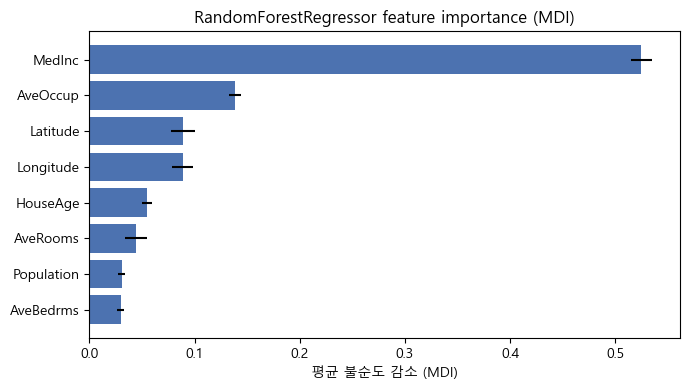

,MDI importance
MedInc,0.524871
AveOccup,0.138443
Latitude,0.088936
Longitude,0.088629
HouseAge,0.054593
AveRooms,0.044272
Population,0.030650
AveBedrms,0.029606


In [27]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_std = pd.Series(np.std([est.feature_importances_ for est in rf.estimators_], axis=0),
                    index=X.columns)[importances.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances.index[::-1], importances.values[::-1],
        xerr=imp_std.values[::-1], color="#4C72B0")
ax.set_xlabel("평균 불순도 감소 (MDI)")
ax.set_title("RandomForestRegressor feature importance (MDI)")
fig.tight_layout()
plt.show()

importances.to_frame("MDI importance")

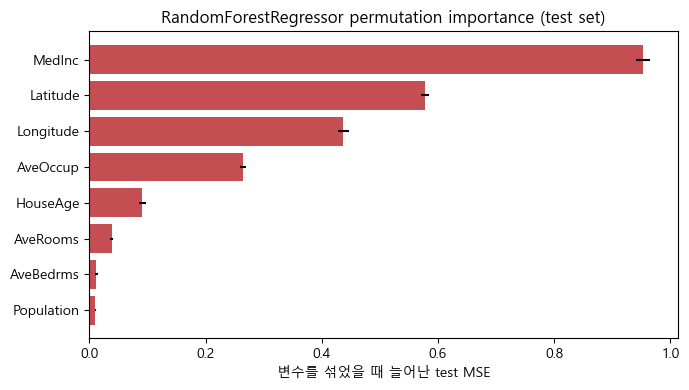

,MDI,MDI 순위,permutation,permutation 순위
MedInc,0.524871,1,0.952352,1
AveOccup,0.138443,2,0.264468,4
Latitude,0.088936,3,0.577773,2
Longitude,0.088629,4,0.436930,3
HouseAge,0.054593,5,0.090872,5
AveRooms,0.044272,6,0.038406,6
Population,0.030650,7,0.010334,8
AveBedrms,0.029606,8,0.012014,7


In [28]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=5,
                              random_state=42, scoring="neg_mean_squared_error")
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X.columns)[perm_imp.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(perm_imp.index[::-1], perm_imp.values[::-1],
        xerr=perm_std.values[::-1], color="#C44E52")
ax.set_xlabel("변수를 섞었을 때 늘어난 test MSE")
ax.set_title("RandomForestRegressor permutation importance (test set)")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "MDI": importances,
    "MDI 순위": importances.rank(ascending=False).astype(int),
    "permutation": perm_imp,
    "permutation 순위": perm_imp.rank(ascending=False).astype(int),
}).sort_values("MDI", ascending=False)

**Q3.7 답**

MDI 기준으로는 MedInc 하나가 전체 중요도의 절반을 넘습니다(0.525). 그다음이 AveOccup 0.138이고 Latitude·Longitude가 각각 0.089로 뒤를 따릅니다. 오차 막대는 트리 100그루 사이의 표준편차인데, 순위가 뒤집힐 만큼 크지는 않습니다.

그런데 permutation importance로 다시 재면 순위가 바뀝니다.

| 변수 | MDI 순위 | permutation 순위 |
|---|---|---|
| MedInc | 1 | 1 |
| AveOccup | 2 | 4 |
| Latitude | 3 | **2** |
| Longitude | 4 | **3** |
| HouseAge | 5 | 5 |
| AveRooms | 6 | 6 |
| Population | 7 | 8 |
| AveBedrms | 8 | 7 |

두 방법이 재는 것이 다르기 때문입니다. MDI는 train에서 그 변수로 분할할 때마다 줄어든 불순도를 합산한 값이고, permutation은 test에서 그 변수만 뒤섞었을 때 늘어난 MSE입니다. 앞은 "학습 중에 얼마나 자주·크게 쓰였나", 뒤는 "없으면 예측이 얼마나 망가지나"에 가깝습니다.

위도와 경도가 MDI에서 낮게 잡히는 건 둘이 같은 정보를 나눠 갖기 때문으로 보입니다. 상관계수가 −0.925라 트리는 매 분할에서 둘 중 하나만 고르게 되고, 공로도 그만큼 쪼개집니다. 상관이 높은 변수 쌍은 permutation에서도 서로를 대신해줘서 과소평가되는 쪽이 보통인데, 그런데도 2·3위로 올라온 걸 보면 캘리포니아 집값에서 위치가 소득 다음으로 중요한 변수라고 판단했습니다.

시각화만 놓고 결론을 내렸다면 "소득과 가구당 인원이 중요하고 위치는 그다음"이라고 적었을 텐데, 두 번째 그림을 보고 생각이 바뀐 부분입니다.

### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

**(BONUS) 1 답**

| 모델 | 다음 학습기를 무엇에 맞추나 | 트리를 어떻게 키우나 | 이번 실험 결과 |
|---|---|---|---|
| AdaBoost | 틀린 샘플의 **가중치**를 키워 다시 학습 | base estimator에 위임 (기본은 깊이 3 트리) | 0.6145 → base 깊이 10에서 0.2483 |
| Gradient Boosting | 지금까지 남은 **잔차**(정확히는 손실의 음의 그래디언트) | level-wise, `max_depth`로 제어 | 0.2277 (500그루, 37초) |
| XGBoost | 잔차 + **2차 미분까지 쓴 근사** | level-wise, 목적함수에 L1/L2 정규화 포함 | 0.1907 (1000그루, 2.3초) |
| LightGBM | 잔차 (GBM과 같음) | **leaf-wise** + 히스토그램 분할 | 0.1858 (1000그루, 8.2초) |

정리하면서 든 생각입니다.

**AdaBoost만 결이 다릅니다.** 나머지 셋이 "직전까지의 오차를 새 트리로 맞힌다"면 AdaBoost는 "틀린 데이터에 가중치를 더 준다"입니다. 이론적으로는 AdaBoost도 지수 손실에 대한 gradient boosting으로 볼 수 있다고 알려져 있지만, 코드에서 손잡이가 드러나는 방식은 확실히 다릅니다. AdaBoost에서 가장 중요한 손잡이는 `estimator`(base) 자체였고, 나머지 셋에서는 `learning_rate`와 트리 수였습니다.

**XGBoost·LightGBM은 GBM의 다른 알고리즘이라기보다 빠른 구현 + 정규화에 가깝다고 판단했습니다.** 근거는 위 비교 정리의 1번입니다. 조건을 똑같이 맞추면 셋이 0.289~0.295로 붙었습니다.

**두 라이브러리의 차이는 트리를 키우는 방향입니다.** XGBoost의 level-wise는 같은 깊이의 노드를 한 층씩 채우고, LightGBM의 leaf-wise는 손실을 가장 많이 줄일 리프 하나만 골라 계속 쪼갭니다. 그래서 LightGBM 쪽이 같은 리프 수로 더 깊고 비대칭인 트리를 만듭니다. 이 노트북 위쪽 안내문의 "데이터가 적으면 overfitting이 일어난다"는 경고가 특히 leaf-wise에 해당하는 이야기로 보입니다.

**넷의 공통점**은 순차적이라는 것입니다. 트리를 만드는 순서 자체는 병렬화할 수 없고, XGBoost나 LightGBM이 말하는 병렬화는 한 트리 안에서 분할 후보를 찾는 과정을 나눠 계산하는 것입니다. 랜덤 포레스트가 트리 100그루를 통째로 병렬로 만들 수 있는 것과 대비되는 지점입니다.

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

In [29]:
censored = housing_df.MedHouseVal >= 5.0
print(f"MedHouseVal 최댓값 {housing_df.MedHouseVal.max()} 에 몰린 행: "
      f"{censored.sum()}개 ({censored.mean():.1%})")
print(f"Latitude-Longitude 상관계수 {housing_df.Latitude.corr(housing_df.Longitude):.3f}")
print(f"AveOccup 최댓값 {housing_df.AveOccup.max():.1f} / AveRooms 최댓값 {housing_df.AveRooms.max():.1f}")

LGB_PARAMS = dict(n_estimators=1000, learning_rate=0.05, num_leaves=31, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)

pred_lgb = lgb_model.predict(X_test)
cut = (y_test >= 5.0).values
print(f"\nLightGBM MSE를 나눠 보면 — 절단행 {cut.sum()}개: "
      f"{mean_squared_error(y_test[cut], pred_lgb[cut]):.4f}"
      f" / 나머지 {(~cut).sum()}개: {mean_squared_error(y_test[~cut], pred_lgb[~cut]):.4f}")

keep_tr, keep_te = y_train < 5.0, y_test < 5.0
pred_keep = lgb.LGBMRegressor(**LGB_PARAMS).fit(X_train[keep_tr], y_train[keep_tr]).predict(X_test[keep_te])
print(f"절단행을 빼고 학습·평가하면: {mean_squared_error(y_test[keep_te], pred_keep):.4f}")

from sklearn.cluster import KMeans

def add_features(frame, km):
    f = frame.copy()
    f["rooms_per_person"] = f["AveRooms"] / f["AveOccup"]
    f["bedrm_ratio"] = f["AveBedrms"] / f["AveRooms"]
    f["geo_cluster"] = km.predict(frame[["Latitude", "Longitude"]])
    return f

km = KMeans(n_clusters=20, n_init=10, random_state=42).fit(X_train[["Latitude", "Longitude"]])
pred_fe = lgb.LGBMRegressor(**LGB_PARAMS).fit(add_features(X_train, km), y_train).predict(add_features(X_test, km))
print(f"파생 변수 3개를 추가하면: {mean_squared_error(y_test, pred_fe):.4f}")

MedHouseVal 최댓값 5.00001 에 몰린 행: 992개 (4.8%)
Latitude-Longitude 상관계수 -0.925
AveOccup 최댓값 1243.3 / AveRooms 최댓값 141.9

LightGBM MSE를 나눠 보면 — 절단행 184개: 0.7480 / 나머지 3944개: 0.1596


절단행을 빼고 학습·평가하면: 0.1536


파생 변수 3개를 추가하면: 0.1826


**(BONUS) 2 답**

이번 실험에서 실제로 효과가 컸던 순서대로 적었습니다.

**1. 모델을 바꾸기 전에 그 모델의 손잡이부터 돌린다.**
AdaBoost 0.6145 → 0.2483(base estimator만 교체)이 이번 과제에서 가장 큰 변화였고, 모델을 바꾼 것(GradientBoosting 0.2277 → LightGBM 0.1858)보다 컸습니다. 부스팅 계열이라면 `learning_rate`를 낮추고 `n_estimators`를 늘리는 짝이 우선이고, LightGBM이면 `num_leaves`와 `min_child_samples`, XGBoost면 `max_depth`와 정규화 항이 그다음이라고 생각합니다.

**2. 차이가 노이즈보다 큰지부터 확인한다.**
분할 시드 7개에서 LightGBM MSE의 표준편차가 0.006이었습니다. 단일 분할의 0.005 차이로 순위를 매기면 시드가 바뀔 때 뒤집힙니다. 모델 선택은 K-fold나 여러 시드 평균으로 하고, 개선 폭이 이 폭보다 작으면 "좋아졌다"고 적지 않는 편이 안전해 보입니다.

**3. 탐색을 손이 아니라 코드로 한다.**
`RandomizedSearchCV`나 Optuna로 위 파라미터들을 함께 봅니다. 부스팅은 early stopping을 켜고 `n_estimators`를 넉넉히 주면 트리 수를 따로 고르지 않아도 됩니다.

**4. 데이터를 손본다.** 이번 데이터에서 눈에 띈 것 세 가지입니다.

- **타깃이 잘려 있습니다.** MedHouseVal 최댓값이 5.00001인데 그 값에만 992개(4.8%)가 몰려 있습니다. 원래 값이 얼마였는지 알 수 없으니 모델이 맞힐 방법이 없습니다. LightGBM 예측을 나눠서 재보면 이 절단행들의 MSE는 0.748로 나머지(0.160)의 4.7배이고, test의 4.5%가 전체 MSE의 약 18%를 만들고 있었습니다.
- **이상치로 보이는 값이 있습니다.** AveOccup 최댓값 1243, AveRooms 최댓값 142는 가구 수가 아주 적은 블록에서 나온 값으로 보입니다. 트리는 이상치에 강한 편이지만 분할 하나를 여기에 쓸 수는 있습니다.
- **위도·경도가 원시 좌표입니다.** 트리는 좌표를 계단 모양으로만 근사합니다. 시험 삼아 좌표를 KMeans로 20개 구역으로 묶은 변수와 `AveRooms / AveOccup`, `AveBedrms / AveRooms` 두 비율을 추가해 LightGBM을 다시 돌리니 0.1858 → 0.1826이 되었습니다. 시드 하나에서만 본 값이라 2번의 기준으로는 아직 확실하다고 말하기 어렵습니다.

**5. 여러 모델을 섞는다.**
LightGBM과 XGBoost 예측을 단순 평균 내면 0.1858 → 0.1844였습니다. 개선 폭 자체는 2번에서 잰 시드 변동(0.006)보다 작지만, 시드 7개 **전부에서** 두 모델 중 나은 쪽보다 낮았고 평균 0.0029만큼 개선되었습니다. 같은 분할 안에서 짝지어 비교하는 것이라 시드 변동과는 성격이 다르다고 판단했습니다.

**생각해볼 지점**

4번의 절단행을 빼고 학습·평가하면 MSE가 0.1858에서 0.1536까지 내려갑니다. 그런데 이건 모델이 좋아진 게 아니라 맞힐 수 없는 문제를 빼서 나온 숫자입니다. 이런 경우 지표를 그대로 두고 "여기는 못 맞힌다"고 적는 게 맞을지, 아니면 절단 여부를 따로 맞히는 분류 문제로 나누는 게 맞을지 궁금합니다. 다른 분들은 어떻게 보시는지 의견을 듣고 싶습니다.